# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [1]:
STUDENT_NAME = "PHẠM TIẾN THỊNH"  # TODO: Họ và tên
STUDENT_ID = "2510233"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: PHẠM TIẾN THỊNH (2510233)


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: /content/data/automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [3]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [4]:
# TODO N1
# shifted_logits = ...
max_logits = np.max(logits, axis = 1, keepdims = True)
shifted_logits = logits - max_logits

# exp_logits = ...
exp_logits = np.exp(shifted_logits)

# class_probabilities = ...
sum_exp = np.sum(exp_logits, axis = 1, keepdims = True)
class_probabilities = exp_logits / sum_exp

# predicted_classes = ...
predicted_classes = np.argmax(class_probabilities, axis = 1)

# confidence_scores = ...
confidence_scores = np.max(class_probabilities, axis = 1)

In [5]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [6]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [7]:
# TODO N2
# train_feature_mean = ...
train_feature_mean = np.mean(X_train, axis = 0)

# train_feature_std = ...
train_feature_std = np.std(X_train, axis = 0)

# X_train_scaled = ...
X_train_scaled = (X_train - train_feature_mean) / train_feature_std

# X_val_scaled = ...
X_val_scaled = (X_val - train_feature_mean) / train_feature_std

In [8]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [9]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [10]:
# TODO N3
# correct_mask = ...
correct_mask = (predicted_classes == true_labels)

# high_confidence_mask = ...
high_confidence_mask = (confidence_scores >= confidence_threshold)

# review_mask = ...
review_mask = ~correct_mask | ~high_confidence_mask

# review_indices = ...
review_indices = np.where(review_mask)[0]

## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [11]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [12]:
# TODO N4
# normalized_batch = ...
normalized_batch = image_batch_uint8.astype(np.float32) / 255.0

# augmented_batch = ...
augmented_batch = normalized_batch[:, :, ::-1, :].copy()

# augmented_batch[0, 0, 0, 0] = ...
augmented_batch[0, 0, 0, 0] = 1.0

# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**

<!-- Viết câu trả lời tại đây. -->
1. Mỗi dòng đại diện cho một mẫu xe trong toàn bộ 1985 Auto Imports.
2. Ký hiệu missing value trong CSV là "?".
3. Symboling là mức đánh giá rủi ro bảo hiểm.

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [13]:
# TODO D1
# raw_df = ...
raw_df = pd.read_csv(DATA_PATH)

# raw_shape = ...
raw_shape = raw_df.shape

# raw_missing_marker_count = ...
raw_missing_marker_count = (raw_df == '?').sum()

display(raw_df.head())

,symboling,normalized_losses,make,fuel_type,aspiration,num_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [14]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [15]:
# TODO D2
# df_clean = ...
df_clean = raw_df.replace('?', np.nan)

# for column in NUMERIC_COLUMNS:
for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column])
#     ...
# missing_by_column = ...
missing_by_column = df_clean.isnull().sum()


### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**

<!-- Viết 3--6 câu tại đây. --> Mỗi cột mang một ý nghĩa khác nhau nên việc fill tất cả bằng cùng một giá trị có thể sẽ dẫn đến những đặc điểm vô lý (ví dụ như num-doors = 0, engine_size = 1,..), ngoài ra thì còn có thể ảnh hưởng đến phân phối của dữ liệu và mối tuong quan giữa các biến số. Có thể lựa chọn việc drop price vì tỉ lệ thiếu so với tổng quan dữ liệu rất nhỏ. Normalized_losses thiếu nhiều dữ liệu hơn các cột khác rất nhiều, điều này sẽ ảnh hưởng đến việc ra quyết định drop hay fill, số lượng thiếu khá cao nên khi drop sẽ mất đi dữ liệu của các cột khác hoặc ảnh hưởng đến phân tích các biến khác. Còn nếu fill thì phải sử dụng các phương pháp khác với việc điền bằng mean/median vì có thể tạo ra 1 đỉnh bất thường tại đó.

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [16]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [17]:
# TODO D3
# analysis_df = ...
analysis_df = df_clean[AUTO_FEATURES].dropna()

# X_auto = ...
X_auto = analysis_df.to_numpy().astype(np.float64)

# auto_feature_mean = ...
auto_feature_mean = np.mean(X_auto, axis = 0)

# auto_feature_std = ...
auto_feature_std = np.std(X_auto, axis = 0)

# X_auto_scaled = ...
X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std

## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [18]:
# TODO D4
# price_index = ...
price_index = AUTO_FEATURES.index('price')

# price_z = ...
price_z = X_auto_scaled[:, price_index]

# price_outlier_mask = ...
price_outlier_mask = np.abs(price_z) > 2

# price_outliers = ...
price_outliers = X_auto[price_outlier_mask]



## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [19]:
# TODO D5
corr_df = df_clean[['engine_size', 'price']].dropna()
# engine_price_corr = ...
engine_price_corr = np.corrcoef(corr_df['engine_size'], corr_df['price'])[0,1]

# price_by_body_style = ...
price_by_body_style = df_clean.groupby('body_style')['price'].mean().sort_index()


# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

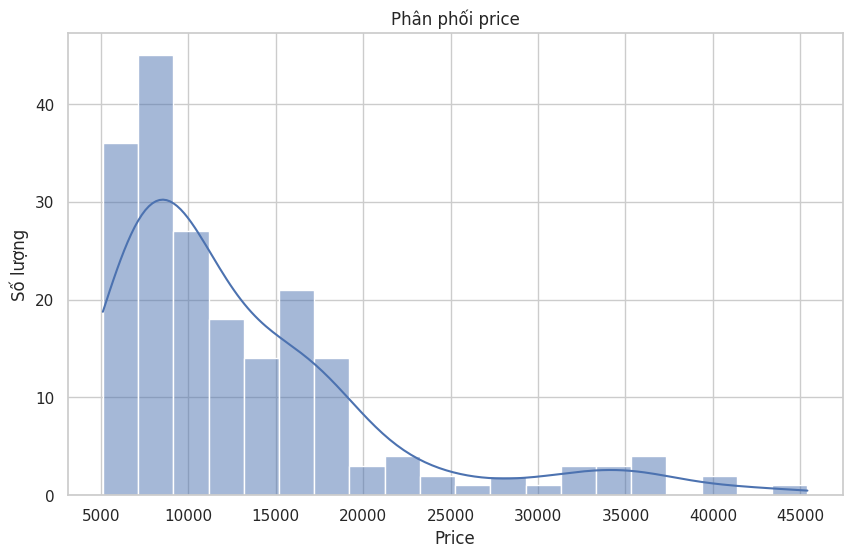

In [20]:
# TODO M2.1: histogram/KDE của price
plt.figure(figsize=(10,6))
price_data = df_clean['price'].dropna()
sns.histplot(data=price_data, bins = 20, kde = True)
plt.title("Phân phối price")
plt.xlabel("Price")
plt.ylabel("Số lượng")
plt.show()

**Nhận xét:** <!-- 1--2 câu --> Biểu đồ thể hiện phân phối lệch phải. Phần lớn các mẫu xe tập trung ở mức giá trung bình thấp (<15000).

## M2.2 Dataset có cân bằng theo body style không?

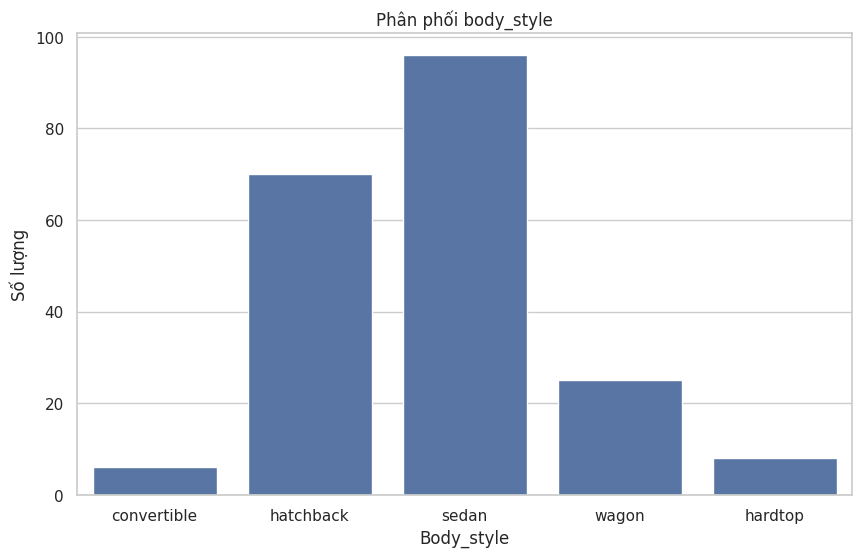

In [21]:
# TODO M2.2: countplot của body_style
plt.figure(figsize=(10,6))
sns.countplot(data=df_clean, x='body_style')
plt.title("Phân phối body_style")
plt.xlabel("Body_style")
plt.ylabel("Số lượng")
plt.show()

**Nhận xét:** <!-- 1--2 câu --> Dataset không cân bằng theo biến body_style, ta có thể thấy rõ rằng nhóm sedan và hatchback chiếm phần lớn trong khi hardtop và converrtible thì có số lượng rất ít (<10 chiếc).

## M2.3 Price khác nhau theo body style ra sao?

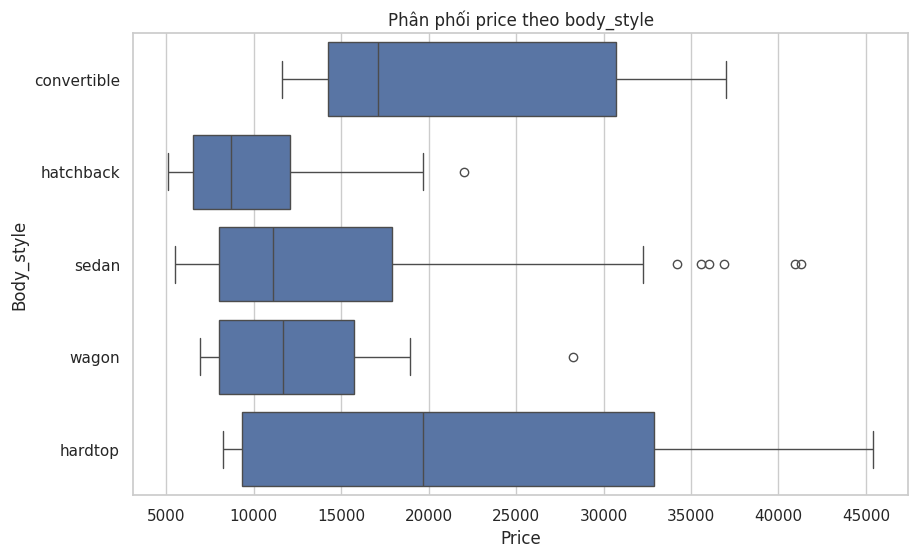

In [22]:
# TODO M2.3: boxplot price theo body_style
plt.figure(figsize=(10,6))
sns.boxplot(data=df_clean, x='price', y='body_style')
plt.title("Phân phối price theo body_style")
plt.xlabel("Price")
plt.ylabel("Body_style")
plt.show()

**Nhận xét:** <!-- 1--2 câu --> Hatchback có mức giá rẻ và ổn định với phần hộp rẩ ngắn trong khi hardtop thì có mức giá biến động mạnh khi phần hộp được thể hiện dài nhất. Dòng sedan thì có nhiều outliers nhất, thể hiện rằng có những mẫu xe "VIP" hơn rất nhiều so với mặt bằng chung của dòng.

## M2.4 Engine size liên quan thế nào tới price?

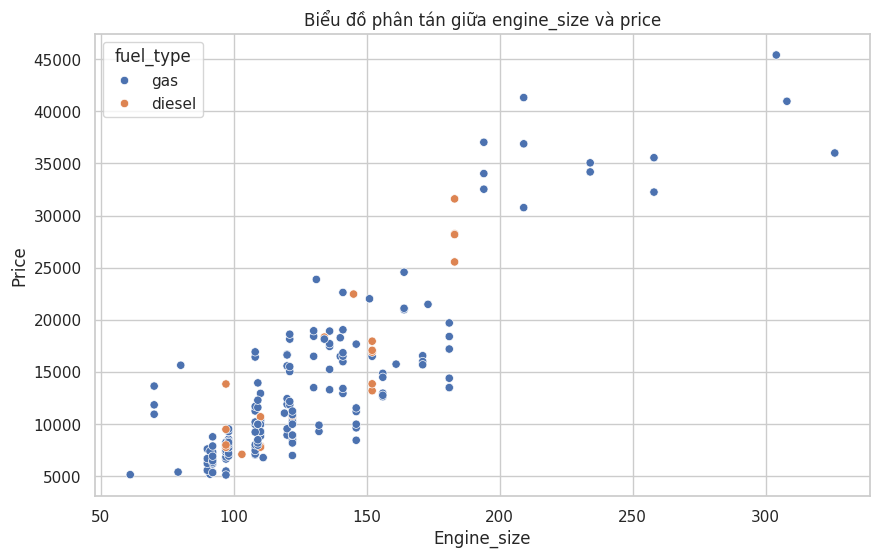

In [23]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_clean, x='engine_size', y='price', hue='fuel_type')
plt.title("Biểu đồ phân tán giữa engine_size và price")
plt.xlabel("Engine_size")
plt.ylabel("Price")
plt.show()

**Nhận xét:** <!-- 1--2 câu --> Số lượng xe chạy bằng gas chiếm ưu thế hoàn toàn so với diesel. Các xe dầu thì nằm trong khoảng giá dưới 30000 và ở phân khúc động cơ kích thước từ khoảng 100 đến dưới 200, còn xe xăng thì trải dài trên toàn bộ phổ dữ liệu.

## M2.5 Các feature numeric tương quan ra sao?

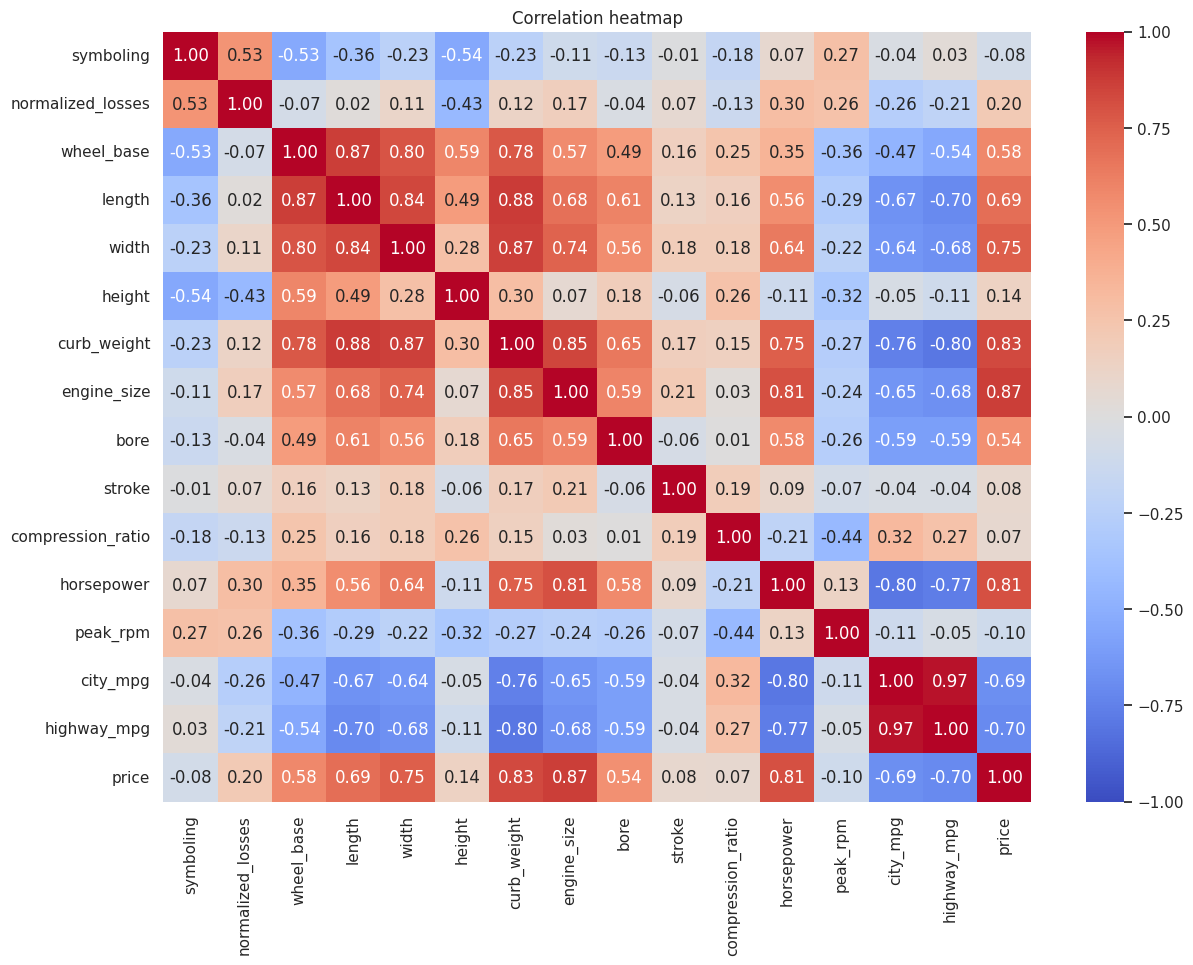

In [24]:
# TODO M2.5: correlation heatmap
numeric_df = df_clean[NUMERIC_COLUMNS]
corr_matrix = numeric_df.corr()
plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, annot=True, fmt =".2f", cmap='coolwarm', vmin = -1, vmax = 1)
plt.title("Correlation heatmap")
plt.show()

**Nhận xét:** <!-- 1--2 câu --> Các yếu tố tỉ lệ mạnh với giá xe: curb_weight, horsepower, engine_size, có nghĩa xe càng to, nặng, động cơ càng mạnh thì giá càng cao. Xuất hiện hiện tượng đa cộng tuyến ở cặp city_mpg và highway_mpg (0.97)

## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

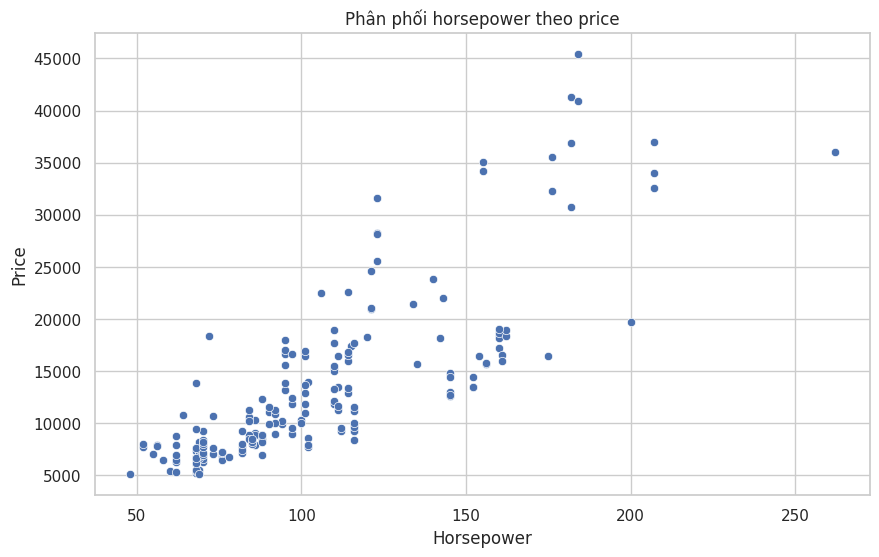

In [25]:
# TODO M2.6: biểu đồ tự chọn
plot_data = df_clean[['horsepower', 'price']].dropna()
plt.figure(figsize=(10,6))
sns.scatterplot(data=plot_data, x='horsepower', y='price')
plt.title("Phân phối horsepower theo price")
plt.xlabel("Horsepower")
plt.ylabel("Price")
plt.show()

**Nhận xét:** <!-- 1--2 câu --> Mã lực và giá xe có mối tương quan khá cao (0.81 ở heatmap), chỉ ra rằng xe càng mạnh thì càng đắt. Với những mẫu xe có giá trung bình thấp (<=20000) thì sức mạnh của động cơ tập trung thành cụm và chủ yếu nhỏ hơn 150 mã lực. Ở mốc trên 150 mã lực thì lại có sự biến động mạnh ở giá xe (cùng là ~150HP nhưng có xe giá <20000 nhưng có xe lại lên tới 35000)

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

<!-- Viết khoảng 150--250 từ. --> Giá xe có tương quan đồng biến tốt với các thông số về mặt sức mạnh và kích thước vật lý của xe: curb_weight 0.83, horsepower 0.81, engine_size 0.87. Mặt khác, hệ số tương quan giữa city/highway_mpg với horsepower rất thấp: lần lượt là -0.8 và -0.77, thể hiện rằng xe càng mạnh thì sẽ càng không tiết kiệm nhiên liệu khi di . Thị trường xe trong dataset chủ yếu nằm ở phân khúc bình dân, với việc các mẫu có giá <15000 chiếm số lượng lớn. Về hạn chế của dataset, đầu tiên là về kích thước của mẫu khá ít, chỉ gồm 205 dòng. Thứ hai là sự phân bổ của nhiều biến bị lệch rất nghiêm trọng: body_style với lệch hẳn về phía sedan (>90 xe) và hatchback (~70 xe) trong khi đặc biệt 2 nhóm convertible và hardtop có số lượng rất ít (cả 2 đều có ít hơn 10 xe), hay sự phân bố với chênh lệch rất lớn giữa xe gas và diesel (~20 cái). Ngoài ra thì data của cột normalized_losses thiếu tới 41 dòng (~20% tổng dữ liệu), đây là tỉ lệ lớn trong một dataset ít như này nên việc drop hay fill đều sẽ ảnh hưởng sai lệch đến các phân phối. Ví dụ về correlation không đồng nghĩa với causation: hệ số tương quan giữa curb_weight và price là 0.83, có nghĩa là xe càng nặng thì giá sẽ càng tăng. Nhưng điều này không có nghĩa là nếu nhà sản xuất độn thêm sắt/thép vào xe, thay bằng những vật liệu có khối lượng cao hơn thì sẽ bán giá cao hơn được. Thực chất thì trọng lượng nặng là do hệ quả của việc chiếc xe được trang bị động cơ to hơn (engine_size), khung xe lớn hơn (height/width) nên xe mới tăng giá. Câu hỏi nên phân tích: yếu tố thương hiệu (make) ảnh hưởng tới giá xe như thế nào?